In [219]:
import pandas as pd
df = pd.read_csv("C:/Users/huang/Desktop/UK Plant-based food_Meat.csv",header=[1, 2])


In [220]:
cols = pd.DataFrame(df.columns.tolist(), columns=["top", "bottom"])
cols["top"] = cols["top"].where(
    ~cols["top"].astype(str).str.contains("Unnamed"),
    None
).ffill()
df.columns = [
    bottom if top == bottom else f"{top}_{bottom}"
    for top, bottom in zip(cols["top"], cols["bottom"])
]
df.columns = [
    str(col).replace("\n", " ").strip()
    for col in df.columns
]
df.columns.tolist()

['None_MARKET',
 'None_CATEGORY',
 'None_TYPE OF REFORMED MEAT',
 'None_TYPE OF SAVOURY INGREDIENTS',
 'Value (in EUR)_MAT 18 end week42',
 'Value (in EUR)_MAT 19 end week42',
 'Value (in EUR)_MAT20 end week42',
 'Value (in GBP)_MAT 18 end week42',
 'Value (in GBP)_MAT 19 end week42',
 'Value (in GBP)_MAT20 end week42',
 'Volume (in kg/l)_MAT 18 end week42',
 'Volume (in kg/l)_MAT 19 end week42',
 'Volume (in kg/l)_MAT20 end week42',
 'Units_MAT 18 end week42',
 'Units_MAT 19 end week42',
 'Units_MAT20 end week42',
 'Units_Unnamed: 16_level_1',
 'Units_Unnamed: 17_level_1',
 'Units_Unnamed: 18_level_1',
 'Units_Unnamed: 19_level_1',
 'Units_Unnamed: 20_level_1',
 'Units_Unnamed: 21_level_1',
 'Units_Unnamed: 22_level_1',
 'Units_Unnamed: 23_level_1',
 'Units_Unnamed: 24_level_1',
 'Units_Unnamed: 25_level_1']

In [221]:
keep_cols = [
    "None_CATEGORY",
    "None_TYPE OF REFORMED MEAT",
    "None_TYPE OF SAVOURY INGREDIENTS",
    "Value (in EUR)_MAT 18 end week42",
    "Value (in EUR)_MAT 19 end week42",
    "Value (in EUR)_MAT20 end week42",
    "Volume (in kg/l)_MAT 18 end week42",
    "Volume (in kg/l)_MAT 19 end week42",
    "Volume (in kg/l)_MAT20 end week42",
]

df_clean = df[keep_cols]


df_clean = df_clean.rename(columns={
    "None_CATEGORY": "CATEGORY",
    "None_TYPE OF REFORMED MEAT": "TYPE OF REFORMED MEAT",
    "None_TYPE OF SAVOURY INGREDIENTS": "TYPE OF SAVOURY INGREDIENTS"
})
df_clean.head()

,CATEGORY,TYPE OF REFORMED MEAT,TYPE OF SAVOURY INGREDIENTS,Value (in EUR)_MAT 18 end week42,Value (in EUR)_MAT 19 end week42,Value (in EUR)_MAT20 end week42,Volume (in kg/l)_MAT 18 end week42,Volume (in kg/l)_MAT 19 end week42,Volume (in kg/l)_MAT20 end week42
0,READY MEALS - MEAT SUBS AMBIENT,NaN,NaN,"3,607,477","4,439,544","7,643,290","574,964","640,485","1,034,098"
1,FRESH READY MEALS - MEAT SUBS,NaN,NaN,"138,968,533","174,387,513","263,678,396","14,725,698","16,629,189","24,972,062"
2,FRESH READY MEALS - MEAT SUBS,SAUSAGE,NaN,"34,245,101","36,375,539","52,632,870","3,742,741","3,756,666","6,020,861"
3,FRESH READY MEALS - MEAT SUBS,SAUSAGE,QUORN,"23,028,622","21,084,160","13,522,644","2,540,091","2,149,982","1,391,533"
4,FRESH READY MEALS - MEAT SUBS,SAUSAGE,VEGETABLE,"7,901,715","8,974,721","15,989,011","873,774","967,577","1,882,757"


In [222]:
meat_categories = [
    "READY MEALS - MEAT SUBS AMBIENT",
    "FRESH READY MEALS - MEAT SUBS",
    "FROZEN MEAT SUBS - READY MEALS"
]

overall_meat = df_clean[
    (df_clean["CATEGORY"].isin(meat_categories)) &
    (df_clean["TYPE OF REFORMED MEAT"].isna()) &
    (df_clean["TYPE OF SAVOURY INGREDIENTS"].isna())
]

overall_meat

,CATEGORY,TYPE OF REFORMED MEAT,TYPE OF SAVOURY INGREDIENTS,Value (in EUR)_MAT 18 end week42,Value (in EUR)_MAT 19 end week42,Value (in EUR)_MAT20 end week42,Volume (in kg/l)_MAT 18 end week42,Volume (in kg/l)_MAT 19 end week42,Volume (in kg/l)_MAT20 end week42
0,READY MEALS - MEAT SUBS AMBIENT,NaN,NaN,"3,607,477","4,439,544","7,643,290","574,964","640,485","1,034,098"
1,FRESH READY MEALS - MEAT SUBS,NaN,NaN,"138,968,533","174,387,513","263,678,396","14,725,698","16,629,189","24,972,062"
138,FROZEN MEAT SUBS - READY MEALS,NaN,NaN,"165,886,777","190,068,798","230,977,754","26,519,064","29,485,954","30,542,170"


In [223]:
numeric_cols = [
    "Value (in EUR)_MAT 18 end week42",
    "Value (in EUR)_MAT 19 end week42",
    "Value (in EUR)_MAT20 end week42",
    "Volume (in kg/l)_MAT 18 end week42",
    "Volume (in kg/l)_MAT 19 end week42",
    "Volume (in kg/l)_MAT20 end week42",
]

df_clean[numeric_cols] = df_clean[numeric_cols].replace(",", "", regex=True)
df_clean[numeric_cols] = df_clean[numeric_cols].apply(pd.to_numeric, errors="coerce")

In [224]:
overall_meat = df_clean[
    (df_clean["CATEGORY"].isin(meat_categories)) &
    (df_clean["TYPE OF REFORMED MEAT"].isna()) &
    (df_clean["TYPE OF SAVOURY INGREDIENTS"].isna())
]

In [225]:
overall_market_size_table = pd.DataFrame({
    "Year": ["MAT 18", "MAT 19", "MAT 20"],
    "Value (EUR)": [
        overall_meat["Value (in EUR)_MAT 18 end week42"].sum(),
        overall_meat["Value (in EUR)_MAT 19 end week42"].sum(),
        overall_meat["Value (in EUR)_MAT20 end week42"].sum()
    ],
    "Volume (kg/l)": [
        overall_meat["Volume (in kg/l)_MAT 18 end week42"].sum(),
        overall_meat["Volume (in kg/l)_MAT 19 end week42"].sum(),
        overall_meat["Volume (in kg/l)_MAT20 end week42"].sum()
    ]
})

overall_market_size_table

,Year,Value (EUR),Volume (kg/l)
0,MAT 18,308462787.0,41819726.0
1,MAT 19,368895855.0,46755628.0
2,MAT 20,502299440.0,56548330.0


In [226]:
overall_market_size_table["Value Growth %"] = (
    overall_market_size_table["Value (EUR)"].pct_change() * 100
)

overall_market_size_table["Volume Growth %"] = (
    overall_market_size_table["Volume (kg/l)"].pct_change() * 100
)

overall_market_size_table

,Year,Value (EUR),Volume (kg/l),Value Growth %,Volume Growth %
0,MAT 18,308462787.0,41819726.0,NaN,NaN
1,MAT 19,368895855.0,46755628.0,19.591688,11.802808
2,MAT 20,502299440.0,56548330.0,36.162940,20.944435


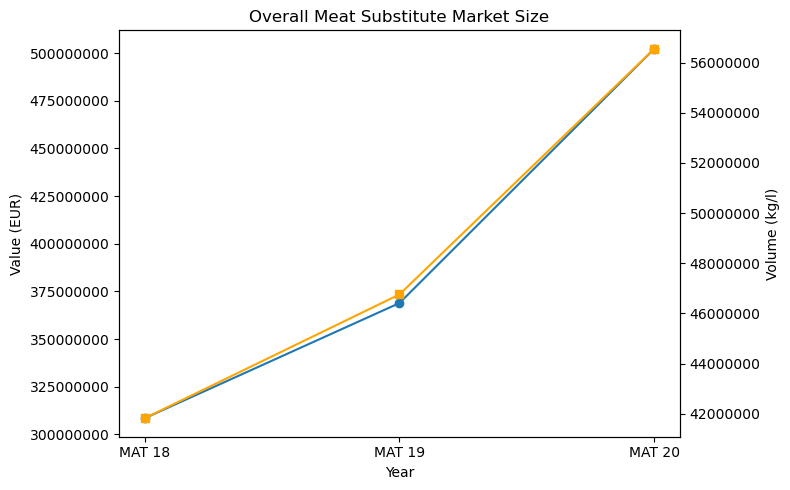

In [227]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(
    overall_market_size_table["Year"],
    overall_market_size_table["Value (EUR)"],
    marker="o",
    label="Value (EUR)"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Value (EUR)")
ax1.ticklabel_format(style="plain", axis="y")

ax2 = ax1.twinx()
ax2.plot(
    overall_market_size_table["Year"],
    overall_market_size_table["Volume (kg/l)"],
    marker="s",
    color="orange",
    label="Volume (kg/l)"
)
ax2.set_ylabel("Volume (kg/l)")
ax2.ticklabel_format(style="plain", axis="y")

plt.title("Overall Meat Substitute Market Size")
fig.tight_layout()
plt.show()

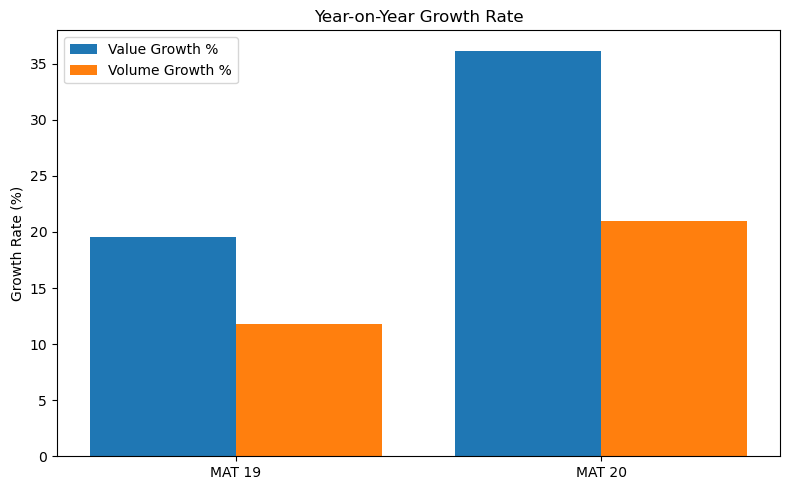

In [228]:
growth_df = overall_market_size_table.dropna(subset=["Value Growth %", "Volume Growth %"])

x = range(len(growth_df))

plt.figure(figsize=(8, 5))

plt.bar(
    [i - 0.2 for i in x],
    growth_df["Value Growth %"],
    width=0.4,
    label="Value Growth %"
)

plt.bar(
    [i + 0.2 for i in x],
    growth_df["Volume Growth %"],
    width=0.4,
    label="Volume Growth %"
)

plt.xticks(x, growth_df["Year"])
plt.ylabel("Growth Rate (%)")
plt.title("Year-on-Year Growth Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [229]:
detail_rows = df_clean[
    (df_clean["CATEGORY"].isin(meat_categories)) &
    (df_clean["TYPE OF REFORMED MEAT"].notna()) &
    (df_clean["TYPE OF SAVOURY INGREDIENTS"].notna())
]

In [230]:
import numpy as np

value_cols = [
    "Value (in EUR)_MAT 18 end week42",
    "Value (in EUR)_MAT 19 end week42",
    "Value (in EUR)_MAT20 end week42"
]

detail_values = detail_rows[value_cols].copy()

#
detail_values = detail_values.apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )
)

#
detail_values_no_zero = detail_values.mask(detail_values == 0, np.nan)

value_descriptive_stats = detail_values_no_zero.describe().T

value_descriptive_stats.index = ["MAT 18", "MAT 19", "MAT 20"]

value_descriptive_stats

,count,mean,std,min,25%,50%,75%,max
MAT 18,68.0,2.043655e+06,4.589689e+06,8.0,20678.25,224544.0,1211555.75,23028622.0
MAT 19,96.0,1.816537e+06,4.303825e+06,5.0,26685.75,253816.0,1513048.00,25871648.0
MAT 20,106.0,2.487532e+06,5.190797e+06,14.0,84193.00,731277.5,2174433.00,33221564.0


In [231]:
value_descriptive_stats = value_descriptive_stats[
    ["count", "mean", "std", "min", "50%", "max"]
].rename(columns={
    "50%": "median"
})

value_descriptive_stats

,count,mean,std,min,median,max
MAT 18,68.0,2.043655e+06,4.589689e+06,8.0,224544.0,23028622.0
MAT 19,96.0,1.816537e+06,4.303825e+06,5.0,253816.0,25871648.0
MAT 20,106.0,2.487532e+06,5.190797e+06,14.0,731277.5,33221564.0


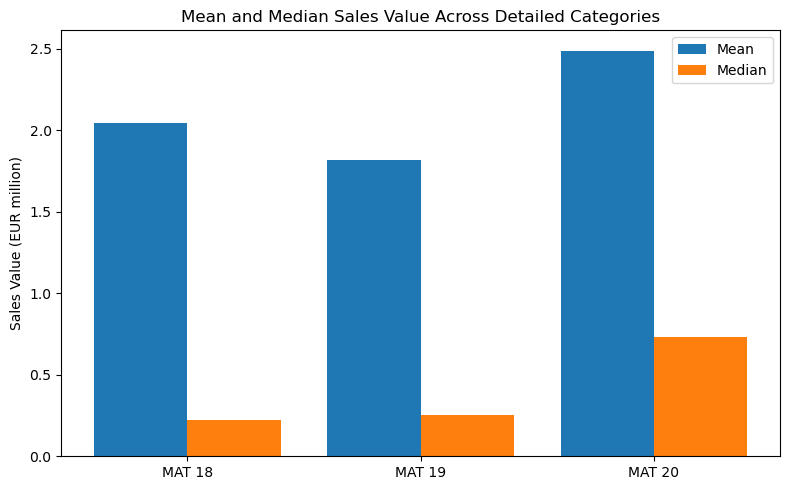

In [232]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

x = range(len(value_descriptive_stats.index))

plt.bar(
    [i - 0.2 for i in x],
    value_descriptive_stats["mean"] / 1_000_000,
    width=0.4,
    label="Mean"
)

plt.bar(
    [i + 0.2 for i in x],
    value_descriptive_stats["median"] / 1_000_000,
    width=0.4,
    label="Median"
)

plt.xticks(x, value_descriptive_stats.index)
plt.ylabel("Sales Value (EUR million)")
plt.title("Mean and Median Sales Value Across Detailed Categories")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\huang\AppData\Local\Temp\ipykernel_36892\3028391430.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


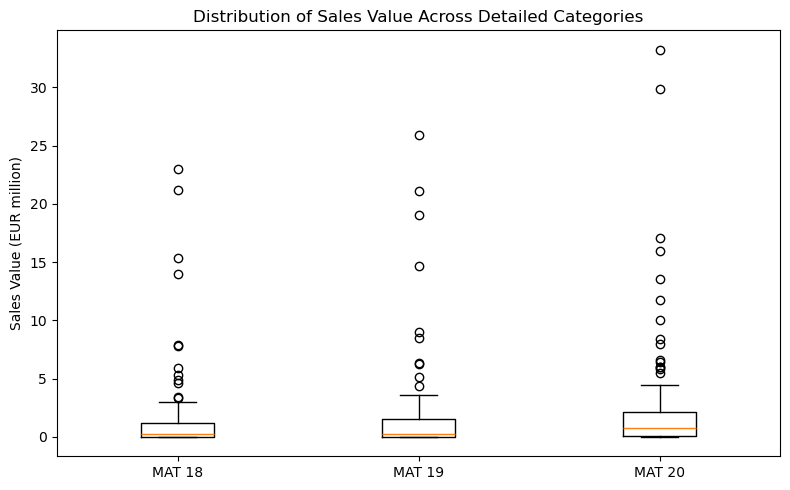

In [233]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        detail_values_no_zero["Value (in EUR)_MAT 18 end week42"].dropna() / 1_000_000,
        detail_values_no_zero["Value (in EUR)_MAT 19 end week42"].dropna() / 1_000_000,
        detail_values_no_zero["Value (in EUR)_MAT20 end week42"].dropna() / 1_000_000,
    ],
    labels=["MAT 18", "MAT 19", "MAT 20"]
)

plt.ylabel("Sales Value (EUR million)")
plt.title("Distribution of Sales Value Across Detailed Categories")
plt.tight_layout()
plt.show()

In [234]:


meat_categories = [
    "READY MEALS - MEAT SUBS AMBIENT",
    "FRESH READY MEALS - MEAT SUBS",
    "FROZEN MEAT SUBS - READY MEALS"
]

num_cols = [
    "Value (in EUR)_MAT 18 end week42",
    "Value (in EUR)_MAT 19 end week42",
    "Value (in EUR)_MAT20 end week42",
    "Volume (in kg/l)_MAT 18 end week42",
    "Volume (in kg/l)_MAT 19 end week42",
    "Volume (in kg/l)_MAT20 end week42",
]

type_detail_rows = df_clean[
    (df_clean["CATEGORY"].isin(meat_categories)) &
    (df_clean["TYPE OF REFORMED MEAT"].notna()) &
    (df_clean["TYPE OF SAVOURY INGREDIENTS"].notna())
].copy()

type_detail_rows[num_cols] = type_detail_rows[num_cols].apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )
)

type_breakdown = (
    type_detail_rows
    .groupby("TYPE OF REFORMED MEAT")[num_cols]
    .sum()
    .reset_index()
)

type_breakdown["Value Growth 18-20 %"] = (
    (type_breakdown["Value (in EUR)_MAT20 end week42"] -
     type_breakdown["Value (in EUR)_MAT 18 end week42"]) /
    type_breakdown["Value (in EUR)_MAT 18 end week42"] * 100
)

type_breakdown["Value Share MAT20 %"] = (
    type_breakdown["Value (in EUR)_MAT20 end week42"] /
    type_breakdown["Value (in EUR)_MAT20 end week42"].sum() * 100
)

type_breakdown

,TYPE OF REFORMED MEAT,Value (in EUR)_MAT 18 end week42,Value (in EUR)_MAT 19 end week42,Value (in EUR)_MAT20 end week42,Volume (in kg/l)_MAT 18 end week42,Volume (in kg/l)_MAT 19 end week42,Volume (in kg/l)_MAT20 end week42,Value Growth 18-20 %,Value Share MAT20 %
0,BITES,354818.0,2527135.0,3663608.0,25648.0,199432.0,284364.0,932.531608,1.389423
1,BLOCK,14002172.0,19326583.0,31412887.0,1964806.0,2634957.0,4176535.0,124.342959,11.913333
2,BURGER,3560558.0,6676211.0,14033245.0,271576.0,504339.0,1099680.0,294.130499,5.322106
3,CHUNKS,793835.0,1537987.0,2438286.0,45288.0,92820.0,143504.0,207.152746,0.924720
4,EGGS,7768611.0,8496031.0,8363246.0,943450.0,963961.0,919896.0,7.654328,3.171760
5,ESCALOPES,3442172.0,3593253.0,6381129.0,298351.0,284290.0,482884.0,85.380887,2.420042
6,FALAFEL,3413.0,3865.0,54261.0,369.0,427.0,5940.0,1489.832992,0.020578
7,FILLET,4679825.0,3740039.0,4224180.0,292974.0,231627.0,301090.0,-9.736368,1.602020
8,KIEV,0.0,213210.0,3131994.0,0.0,17325.0,252791.0,inf,1.187808
9,MEAL,17044361.0,17778765.0,18793678.0,2924421.0,2324359.0,2268057.0,10.263318,7.127500


In [235]:
type_breakdown["Value Change 18-20"] = (
    type_breakdown["Value (in EUR)_MAT20 end week42"] -
    type_breakdown["Value (in EUR)_MAT 18 end week42"]
)

type_breakdown["Volume Change 18-20"] = (
    type_breakdown["Volume (in kg/l)_MAT20 end week42"] -
    type_breakdown["Volume (in kg/l)_MAT 18 end week42"]
)

In [236]:
change_summary = type_breakdown[
    [
        "TYPE OF REFORMED MEAT",
        "Value (in EUR)_MAT 18 end week42",
        "Value (in EUR)_MAT20 end week42",
        "Value Change 18-20",
        "Value Growth 18-20 %",
        "Volume Change 18-20"
    ]
].sort_values("Value Change 18-20", ascending=False)

change_summary

,TYPE OF REFORMED MEAT,Value (in EUR)_MAT 18 end week42,Value (in EUR)_MAT20 end week42,Value Change 18-20,Value Growth 18-20 %,Volume Change 18-20
17,SAUSAGE,34245101.0,52632868.0,18387767.0,53.694591,2278121.0
1,BLOCK,14002172.0,31412887.0,17410715.0,124.342959,2211729.0
15,PIECES,10448301.0,24636180.0,14187879.0,135.791254,871099.0
18,SLICES,22558018.0,36411827.0,13853809.0,61.414123,672377.0
2,BURGER,3560558.0,14033245.0,10472687.0,294.130499,828104.0
13,OTHER,743267.0,9940926.0,9197659.0,1237.463657,638952.0
11,MINCE,5438490.0,13920836.0,8482346.0,155.968771,898349.0
10,MEATBALLS,1180087.0,6850645.0,5670558.0,480.520335,589138.0
16,ROLL,5948405.0,10858531.0,4910126.0,82.545254,362156.0
0,BITES,354818.0,3663608.0,3308790.0,932.531608,258716.0


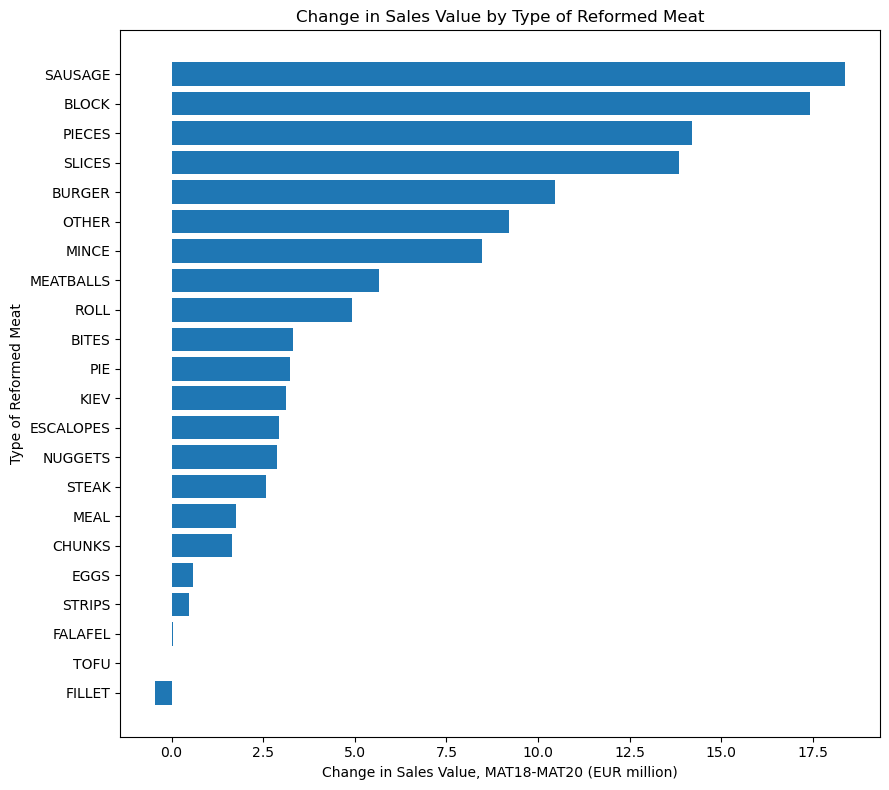

In [237]:
plot_change = change_summary.sort_values("Value Change 18-20", ascending=True)

plt.figure(figsize=(9, 8))

plt.barh(
    plot_change["TYPE OF REFORMED MEAT"],
    plot_change["Value Change 18-20"] / 1_000_000
)

plt.xlabel("Change in Sales Value, MAT18-MAT20 (EUR million)")
plt.ylabel("Type of Reformed Meat")
plt.title("Change in Sales Value by Type of Reformed Meat")
plt.tight_layout()
plt.show()

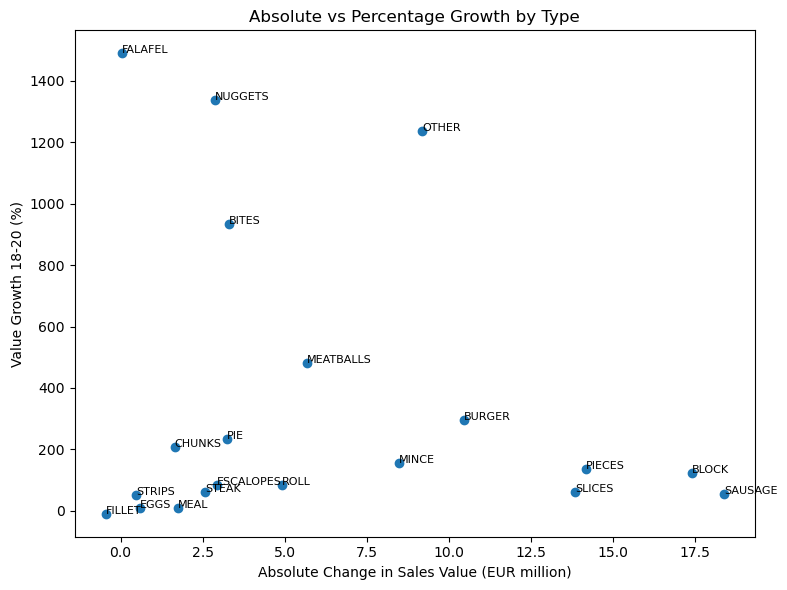

In [238]:
scatter_df = type_breakdown.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["Value Change 18-20", "Value Growth 18-20 %"]
)

plt.figure(figsize=(8, 6))

plt.scatter(
    scatter_df["Value Change 18-20"] / 1_000_000,
    scatter_df["Value Growth 18-20 %"]
)

for _, row in scatter_df.iterrows():
    plt.text(
        row["Value Change 18-20"] / 1_000_000,
        row["Value Growth 18-20 %"],
        row["TYPE OF REFORMED MEAT"],
        fontsize=8
    )

plt.xlabel("Absolute Change in Sales Value (EUR million)")
plt.ylabel("Value Growth 18-20 (%)")
plt.title("Absolute vs Percentage Growth by Type")
plt.tight_layout()
plt.show()

In [240]:
import re
df_youtube = pd.read_csv("C:/Users/huang/Desktop/youtube.csv")

df_youtube.head()

,video_id,url,title,upload_date,channel,summary,narratives,view_count,like_count,comment_count,transcript_source,description
0,7dQdSLCvlKo,https://www.youtube.com/watch?v=7dQdSLCvlKo,Shifting consumers behavior towards healthier ...,2020-11-17,EAT,This project was launched by WBCSD’s FReSH (Fo...,health; environment,1580,19.0,NaN,NaN,This project was launched by WBCSD’s FReSH (Fo...
1,Hngvu6EpgzQ,https://www.youtube.com/watch?v=Hngvu6EpgzQ,2020 Global Plant-Forward Culinary Summit: Pla...,2020-06-10,The Culinary Institute of America,“Plant-Forward and the Consumer: Bridging the ...,NaN,877,11.0,0.0,NaN,“Plant-Forward and the Consumer: Bridging the ...
2,U5fww3Jfqeg,https://www.youtube.com/watch?v=U5fww3Jfqeg,How to attract vegan customers - with Kate Str...,2020-02-13,Promote Vegan,The opportunities in the vegan and plant-based...,identity_lifestyle; innovation_market; environ...,52,1.0,0.0,NaN,The opportunities in the vegan and plant-based...
3,zxhGbwYLzXo,https://www.youtube.com/watch?v=zxhGbwYLzXo,Vegan steak that looks and tastes JUST like me...,2018-05-19,"Xion Gion Co., LTD",Share this article Share The new plant-based s...,innovation_market; identity_lifestyle; taste_c...,17,0.0,0.0,NaN,A plant-based 'steak' that is said to look and...
4,xEIJneiPo88,https://www.youtube.com/watch?v=xEIJneiPo88,Vegan steak that looks and tastes JUST like me...,2018-05-15,"TIN AN CO., LTD",Share this article Share The new plant-based s...,innovation_market; identity_lifestyle; taste_c...,24,0.0,0.0,NaN,★More ABS NEWS - Entertainment Video►► A plant...


In [241]:
themes = {
    "Taste / Sensory": [
        "taste", "tasty", "delicious", "flavour", "flavor", "juicy",
        "crispy", "texture", "mouthfeel", "yummy"
    ],
    "Health / Nutrition": [
        "healthy", "health", "protein", "nutrition", "nutritious",
        "low fat", "high protein", "balanced", "calories", "diet"
    ],
    "Sustainability / Environment": [
        "sustainable", "sustainability", "planet", "climate",
        "carbon", "environment", "eco", "green", "emissions"
    ],
    "Ethics / Animal Welfare": [
        "animal", "cruelty free", "cruelty-free", "welfare",
        "vegan", "vegetarian", "meat free", "meat-free"
    ],
    "Convenience / Everyday Meals": [
        "easy", "quick", "simple", "ready meal", "recipe",
        "cook", "meal", "lunch", "dinner", "family"
    ],
    "Innovation / Future Food": [
        "future", "innovation", "new", "alternative", "plant based",
        "plant-based", "meat substitute", "meat alternative"
    ]
}

In [242]:
def assign_themes(text):
    text = str(text).lower()
    matched = []

    for theme, keywords in themes.items():
        for keyword in keywords:
            pattern = r"\b" + re.escape(keyword) + r"\b"
            if re.search(pattern, text):
                matched.append(theme)
                break

    return matched

df_youtube["themes"] = df_youtube["description"].apply(assign_themes)

df_youtube[["description", "themes"]].head()

,description,themes
0,This project was launched by WBCSD’s FReSH (Fo...,"[Health / Nutrition, Sustainability / Environm..."
1,“Plant-Forward and the Consumer: Bridging the ...,[]
2,The opportunities in the vegan and plant-based...,"[Sustainability / Environment, Ethics / Animal..."
3,A plant-based 'steak' that is said to look and...,"[Taste / Sensory, Health / Nutrition, Sustaina..."
4,★More ABS NEWS - Entertainment Video►► A plant...,"[Taste / Sensory, Health / Nutrition, Sustaina..."


In [243]:
theme_counts = (
    df_youtube
    .explode("themes")
    .dropna(subset=["themes"])
    ["themes"]
    .value_counts()
    .reset_index()
)

theme_counts.columns = ["Theme", "Number of Videos"]

theme_counts["Share of Videos %"] = (
    theme_counts["Number of Videos"] / len(df_youtube) * 100
)

theme_counts

,Theme,Number of Videos,Share of Videos %
0,Innovation / Future Food,383,54.792561
1,Ethics / Animal Welfare,369,52.789700
2,Health / Nutrition,284,40.629471
3,Convenience / Everyday Meals,204,29.184549
4,Sustainability / Environment,155,22.174535
5,Taste / Sensory,123,17.596567


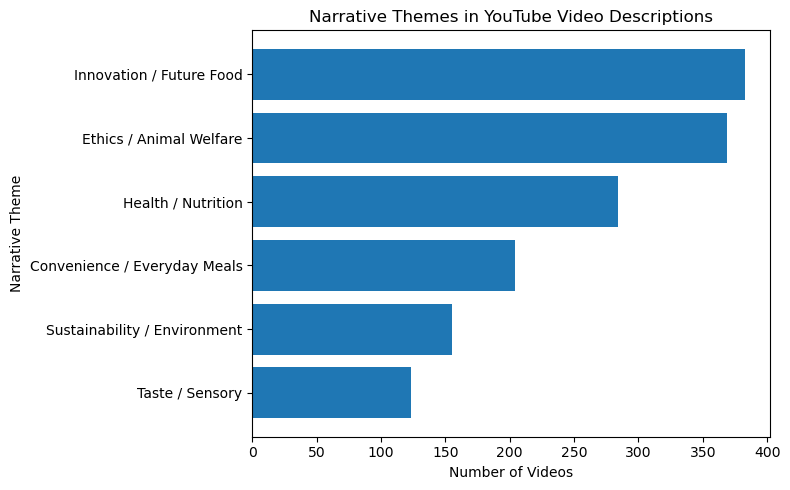

In [244]:
plot_df = theme_counts.sort_values("Number of Videos")

plt.figure(figsize=(8, 5))

plt.barh(
    plot_df["Theme"],
    plot_df["Number of Videos"]
)

plt.xlabel("Number of Videos")
plt.ylabel("Narrative Theme")
plt.title("Narrative Themes in YouTube Video Descriptions")
plt.tight_layout()
plt.show()

In [245]:
for theme in themes.keys():
    examples = df_youtube[
        df_youtube["themes"].apply(lambda x: theme in x)
    ][["title", "description"]].head(3)

    print("\n" + theme)
    display(examples)


Taste / Sensory


,title,description
3,Vegan steak that looks and tastes JUST like me...,A plant-based 'steak' that is said to look and...
4,Vegan steak that looks and tastes JUST like me...,★More ABS NEWS - Entertainment Video►► A plant...
5,Vegan steak that looks and tastes JUST like me...,A plant-based 'steak' that is said to look and...



Health / Nutrition


,title,description
0,Shifting consumers behavior towards healthier ...,This project was launched by WBCSD’s FReSH (Fo...
3,Vegan steak that looks and tastes JUST like me...,A plant-based 'steak' that is said to look and...
4,Vegan steak that looks and tastes JUST like me...,★More ABS NEWS - Entertainment Video►► A plant...



Sustainability / Environment


...

,title,description
2,How to attract vegan customers - with Kate Str...,The opportunities in the vegan and plant-based...
3,Vegan steak that looks and tastes JUST like me...,A plant-based 'steak' that is said to look and...
4,Vegan steak that looks and tastes JUST like me...,★More ABS NEWS - Entertainment Video►► A plant...



Convenience / Everyday Meals


,title,description
10,Career Change: The Questions You Need to Ask Y...,Having successfully navigated the challenges o...
11,"Goodbye Sugar, Hello Flavor | CalFresh Healthy...","For this go-getter dad, sugary sports drinks w..."
17,Cook along with Jasmine Harman - Greek Mezze P...,Join Jasmine Harman – fabulous UK TV presenter...



Innovation / Future Food


,title,description
2,How to attract vegan customers - with Kate Str...,The opportunities in the vegan and plant-based...
3,Vegan steak that looks and tastes JUST like me...,A plant-based 'steak' that is said to look and...
4,Vegan steak that looks and tastes JUST like me...,★More ABS NEWS - Entertainment Video►► A plant...


In [246]:
df_youtube["upload_date"] = pd.to_datetime(df_youtube["upload_date"], errors="coerce")

df_youtube["Year"] = df_youtube["upload_date"].dt.year

df_youtube[["upload_date", "Year"]].head()

,upload_date,Year
0,2020-11-17,2020
1,2020-06-10,2020
2,2020-02-13,2020
3,2018-05-19,2018
4,2018-05-15,2018


In [247]:
metadata_cols = ["view_count", "like_count", "comment_count"]

df_youtube[metadata_cols] = df_youtube[metadata_cols].apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )
)

In [248]:
youtube_descriptive_stats = df_youtube[metadata_cols].describe().T

youtube_descriptive_stats = youtube_descriptive_stats[
    ["count", "mean", "std", "min", "50%", "max"]
].rename(columns={
    "50%": "median"
})

youtube_descriptive_stats

,count,mean,std,min,median,max
view_count,699.0,966778.711016,1.305368e+07,0.0,1579.0,329996180.0
like_count,684.0,19981.011696,2.348831e+05,0.0,36.0,5480664.0
comment_count,665.0,779.810526,7.269136e+03,0.0,10.0,165671.0


In [249]:
youtube_yearly_stats = (
    df_youtube
    .groupby("Year")[metadata_cols]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

youtube_yearly_stats

view_count                                                    like_count  \
          count          mean  median           std min        max      count   
Year                                                                            
2017         79  1.018039e+05  1868.0  3.616144e+05   2    2898234         75   
2018        120  5.209306e+05  2434.5  2.233779e+06   0   19872689        119   
2019        210  1.933331e+06  1211.5  2.288856e+07   4  329996180        205   
2020        290  6.869812e+05  1401.0  5.436022e+06   1   76472606        285   

                                                         comment_count  \
              mean median            std  min        max         count   
Year                                                                     
2017   2009.000000   41.0    4869.302525  0.0    30142.0            75   
2018  12153.084034   62.0   64987.225168  0.0   649640.0           118   
2019  34161.926829   30.0  384566.196490  0.0  5480664.0           195   
2020  17778.684211   29.0  156289.702438  0.0  2350064.0           277   

                                                       
             mean median           std  min       max  
Year                                                   
2017   206.093333   34.0    508.071052  0.0    2349.0  
2018   956.110169   15.0   5757.875601  0.0   61463.0  
2019  1218.702564   10.0  11897.268539  0.0  165671.0  
2020   551.079422    6.0   3635.487500  0.0   54151.0

In [250]:
youtube_yearly_stats.columns = [
    f"{metric}_{stat}" for metric, stat in youtube_yearly_stats.columns
]

youtube_yearly_stats = youtube_yearly_stats.reset_index()

youtube_yearly_stats

,Year,view_count_count,view_count_mean,view_count_median,view_count_std,view_count_min,view_count_max,like_count_count,like_count_mean,like_count_median,like_count_std,like_count_min,like_count_max,comment_count_count,comment_count_mean,comment_count_median,comment_count_std,comment_count_min,comment_count_max
0,2017,79,1.018039e+05,1868.0,3.616144e+05,2,2898234,75,2009.000000,41.0,4869.302525,0.0,30142.0,75,206.093333,34.0,508.071052,0.0,2349.0
1,2018,120,5.209306e+05,2434.5,2.233779e+06,0,19872689,119,12153.084034,62.0,64987.225168,0.0,649640.0,118,956.110169,15.0,5757.875601,0.0,61463.0
2,2019,210,1.933331e+06,1211.5,2.288856e+07,4,329996180,205,34161.926829,30.0,384566.196490,0.0,5480664.0,195,1218.702564,10.0,11897.268539,0.0,165671.0
3,2020,290,6.869812e+05,1401.0,5.436022e+06,1,76472606,285,17778.684211,29.0,156289.702438,0.0,2350064.0,277,551.079422,6.0,3635.487500,0.0,54151.0


In [251]:
youtube_yearly_trend = (
    df_youtube
    .groupby("Year")
    .agg(
        Number_of_Videos=("video_id", "count"),
        Total_Views=("view_count", "sum"),
        Average_Views=("view_count", "mean"),
        Total_Likes=("like_count", "sum"),
        Average_Likes=("like_count", "mean"),
        Total_Comments=("comment_count", "sum"),
        Average_Comments=("comment_count", "mean")
    )
    .reset_index()
)

youtube_yearly_trend

,Year,Number_of_Videos,Total_Views,Average_Views,Total_Likes,Average_Likes,Total_Comments,Average_Comments
0,2017,79,8042512,1.018039e+05,150675.0,2009.000000,15457.0,206.093333
1,2018,120,62511672,5.209306e+05,1446217.0,12153.084034,112821.0,956.110169
2,2019,210,405999596,1.933331e+06,7003195.0,34161.926829,237647.0,1218.702564
3,2020,290,199224539,6.869812e+05,5066925.0,17778.684211,152649.0,551.079422


In [252]:
youtube_yearly_trend["Views Growth %"] = (
    youtube_yearly_trend["Total_Views"].pct_change() * 100
)

youtube_yearly_trend["Likes Growth %"] = (
    youtube_yearly_trend["Total_Likes"].pct_change() * 100
)

youtube_yearly_trend["Comments Growth %"] = (
    youtube_yearly_trend["Total_Comments"].pct_change() * 100
)

youtube_yearly_trend

,Year,Number_of_Videos,Total_Views,Average_Views,Total_Likes,Average_Likes,Total_Comments,Average_Comments,Views Growth %,Likes Growth %,Comments Growth %
0,2017,79,8042512,1.018039e+05,150675.0,2009.000000,15457.0,206.093333,NaN,NaN,NaN
1,2018,120,62511672,5.209306e+05,1446217.0,12153.084034,112821.0,956.110169,677.265511,859.825452,629.902310
2,2019,210,405999596,1.933331e+06,7003195.0,34161.926829,237647.0,1218.702564,549.478062,384.242337,110.640750
3,2020,290,199224539,6.869812e+05,5066925.0,17778.684211,152649.0,551.079422,-50.929868,-27.648380,-35.766494


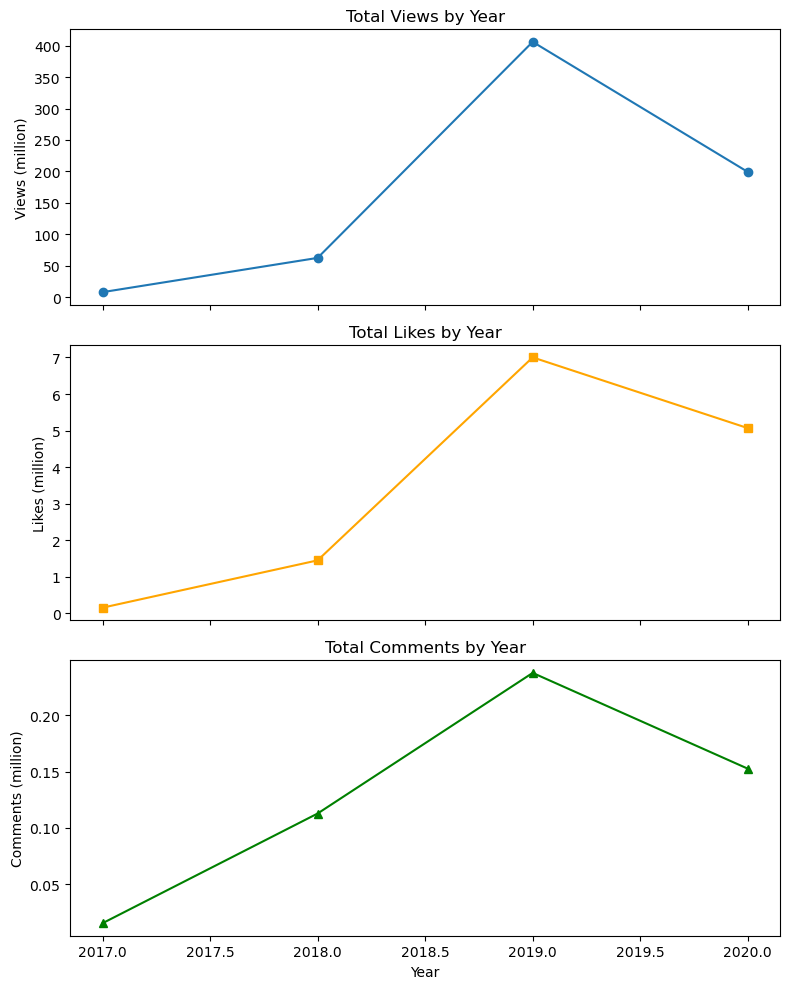

In [255]:
plot_trend = youtube_yearly_trend.copy()

plot_trend["Total Views (million)"] = plot_trend["Total_Views"] / 1_000_000
plot_trend["Total Likes (million)"] = plot_trend["Total_Likes"] / 1_000_000
plot_trend["Total Comments (million)"] = plot_trend["Total_Comments"] / 1_000_000

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes[0].plot(plot_trend["Year"], plot_trend["Total Views (million)"], marker="o")
axes[0].set_ylabel("Views (million)")
axes[0].set_title("Total Views by Year")

axes[1].plot(plot_trend["Year"], plot_trend["Total Likes (million)"], marker="s", color="orange")
axes[1].set_ylabel("Likes (million)")
axes[1].set_title("Total Likes by Year")

axes[2].plot(plot_trend["Year"], plot_trend["Total Comments (million)"], marker="^", color="green")
axes[2].set_ylabel("Comments (million)")
axes[2].set_title("Total Comments by Year")
axes[2].set_xlabel("Year")

plt.tight_layout()
plt.show()

In [256]:
theme_yearly_counts = (
    df_youtube
    .explode("themes")
    .dropna(subset=["themes"])
    .groupby(["Year", "themes"])
    .size()
    .reset_index(name="Number of Videos")
)

theme_yearly_counts

,Year,themes,Number of Videos
0,2017,Convenience / Everyday Meals,17
1,2017,Ethics / Animal Welfare,40
2,2017,Health / Nutrition,40
3,2017,Innovation / Future Food,36
4,2017,Sustainability / Environment,10
5,2017,Taste / Sensory,7
6,2018,Convenience / Everyday Meals,36
7,2018,Ethics / Animal Welfare,69
8,2018,Health / Nutrition,44
9,2018,Innovation / Future Food,64


In [257]:
theme_yearly_wide = theme_yearly_counts.pivot_table(
    index="Year",
    columns="themes",
    values="Number of Videos",
    fill_value=0
).reset_index()

theme_yearly_wide

themes,Year,Convenience / Everyday Meals,Ethics / Animal Welfare,Health / Nutrition,Innovation / Future Food,Sustainability / Environment,Taste / Sensory
0,2017,17.0,40.0,40.0,36.0,10.0,7.0
1,2018,36.0,69.0,44.0,64.0,19.0,21.0
2,2019,68.0,119.0,89.0,123.0,65.0,37.0
3,2020,83.0,141.0,111.0,160.0,61.0,58.0


In [258]:
theme_cols = theme_yearly_wide.columns.drop("Year")

theme_yearly_share = theme_yearly_wide.copy()

theme_yearly_share[theme_cols] = (
    theme_yearly_share[theme_cols]
    .div(theme_yearly_share[theme_cols].sum(axis=1), axis=0)
    * 100
)

theme_yearly_share

themes,Year,Convenience / Everyday Meals,Ethics / Animal Welfare,Health / Nutrition,Innovation / Future Food,Sustainability / Environment,Taste / Sensory
0,2017,11.333333,26.666667,26.666667,24.000000,6.666667,4.666667
1,2018,14.229249,27.272727,17.391304,25.296443,7.509881,8.300395
2,2019,13.572854,23.752495,17.764471,24.550898,12.974052,7.385230
3,2020,13.517915,22.964169,18.078176,26.058632,9.934853,9.446254


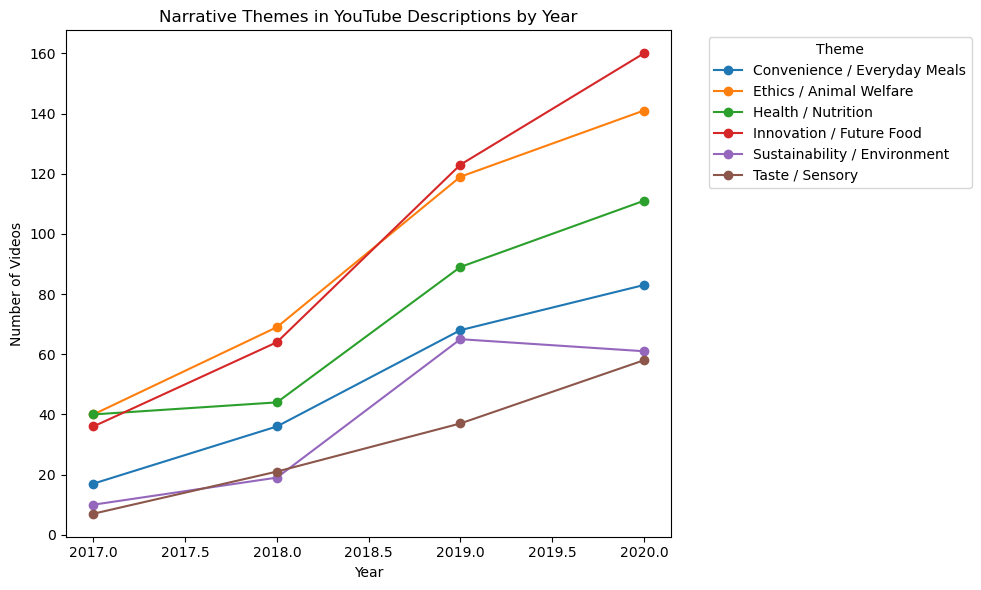

In [259]:
theme_yearly_wide.set_index("Year").plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.xlabel("Year")
plt.ylabel("Number of Videos")
plt.title("Narrative Themes in YouTube Descriptions by Year")
plt.legend(title="Theme", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

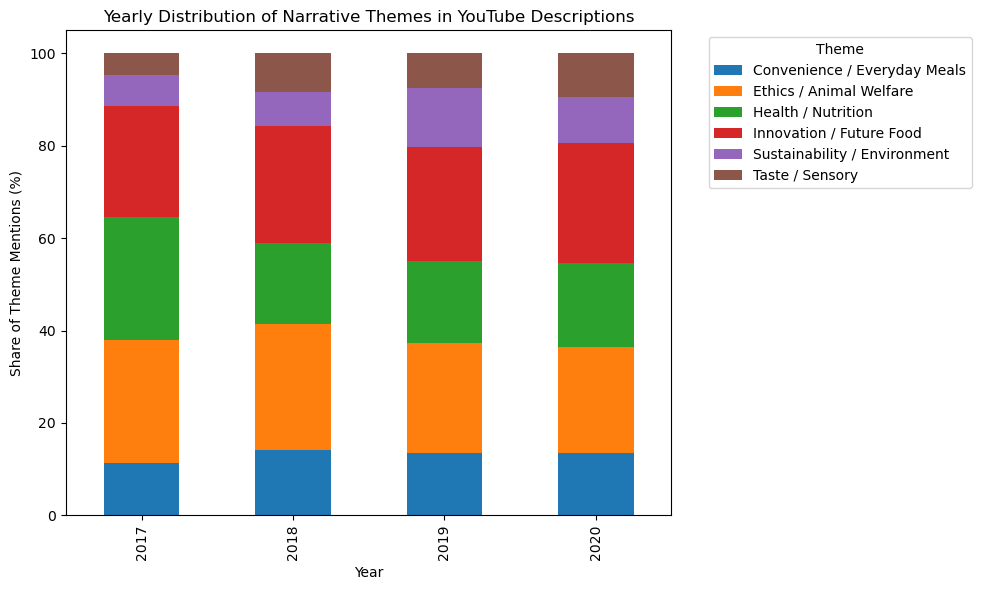

In [260]:
theme_yearly_share.set_index("Year").plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Year")
plt.ylabel("Share of Theme Mentions (%)")
plt.title("Yearly Distribution of Narrative Themes in YouTube Descriptions")
plt.legend(title="Theme", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [261]:
sales_yearly = pd.DataFrame({
    "Year": [2018, 2019, 2020],
    "Value (EUR)": overall_market_size_table["Value (EUR)"].values,
    "Volume (kg/l)": overall_market_size_table["Volume (kg/l)"].values
})

sales_yearly

,Year,Value (EUR),Volume (kg/l)
0,2018,308462787.0,41819726.0
1,2019,368895855.0,46755628.0
2,2020,502299440.0,56548330.0


In [262]:
theme_yearly_counts = (
    df_youtube
    .explode("themes")
    .dropna(subset=["themes"])
    .groupby(["Year", "themes"])
    .size()
    .reset_index(name="Theme Count")
)

theme_wide = theme_yearly_counts.pivot_table(
    index="Year",
    columns="themes",
    values="Theme Count",
    fill_value=0
).reset_index()

theme_wide

themes,Year,Convenience / Everyday Meals,Ethics / Animal Welfare,Health / Nutrition,Innovation / Future Food,Sustainability / Environment,Taste / Sensory
0,2017,17.0,40.0,40.0,36.0,10.0,7.0
1,2018,36.0,69.0,44.0,64.0,19.0,21.0
2,2019,68.0,119.0,89.0,123.0,65.0,37.0
3,2020,83.0,141.0,111.0,160.0,61.0,58.0


In [263]:
correlation_data = sales_yearly.merge(
    theme_wide,
    on="Year",
    how="left"
).fillna(0)

correlation_data

,Year,Value (EUR),Volume (kg/l),Convenience / Everyday Meals,Ethics / Animal Welfare,Health / Nutrition,Innovation / Future Food,Sustainability / Environment,Taste / Sensory
0,2018,308462787.0,41819726.0,36.0,69.0,44.0,64.0,19.0,21.0
1,2019,368895855.0,46755628.0,68.0,119.0,89.0,123.0,65.0,37.0
2,2020,502299440.0,56548330.0,83.0,141.0,111.0,160.0,61.0,58.0


In [264]:
correlation_matrix = correlation_data.drop(columns="Year").corr()

sales_theme_corr = correlation_matrix.loc[
    theme_wide.columns.drop("Year"),
    ["Value (EUR)", "Volume (kg/l)"]
]

sales_theme_corr

,Value (EUR),Volume (kg/l)
themes,,
Convenience / Everyday Meals,0.913135,0.923380
Ethics / Animal Welfare,0.906921,0.917521
Health / Nutrition,0.917250,0.927252
Innovation / Future Food,0.940885,0.949337
Sustainability / Environment,0.685007,0.703634
Taste / Sensory,0.990745,0.993927


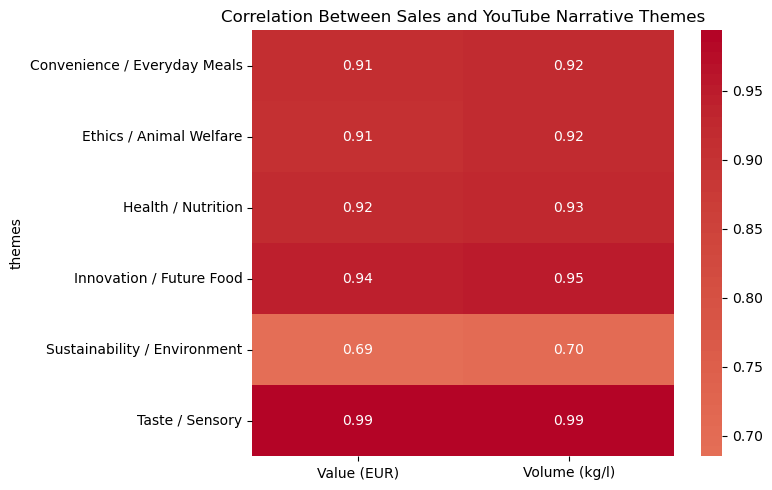

In [265]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.heatmap(
    sales_theme_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Between Sales and YouTube Narrative Themes")
plt.tight_layout()
plt.show()